In [ ]:
!pip install astropy astroquery -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize
import requests
from io import BytesIO

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
# JWST First Light image - Southern Ring Nebula (NGC 3132)
# NIRCam F356 filter - Near Infrared
# Source: MAST / STScI Public archive

url = "https://mast.stsci.edu/api/v0.1/Download/file?uri=mast:JWST/product/jw02733-o001_t001_nircam_clear-f356w_i2d.fits"

print("Fetching JWST data from MAST archive ...")
response = requests.get(url, stream=True)
# Let's check what we actually got back
print(f"Response status: {response.status_code}")
print(f"Content type: {response.headers.get('content-type')}")
print(f"First 200 bytes: {response.content[:200]}")
with fits.open(BytesIO(response.content)) as hdul:
  hdul.info()
  image_data = hdul['SCI'].data
  header = hdul['SCI'].header

print(f"\nImage shape: {image_data.shape}")
print(f"Data type: {image_data.dtype}")
print(f"Min value: {np.nanmin(image_data):.4f}")
print(f"Max value: {np.nanmax(image_data):.4f}")

Fetching JWST data from MAST archive ...
Response status: 200
Content type: application/octet-stream
First 200 bytes: b'SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number '
Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     279   ()      
  1  SCI           1 ImageHDU        75   (2356, 2348)   float32   
  2  ERR           1 ImageHDU        10   (2356, 2348)   float32   
  3  CON           1 ImageHDU        10   (2356, 2348, 1)   int32   
  4  WHT           1 ImageHDU         9   (2356, 2348)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (2356, 2348)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (2356, 2348)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (2356, 2348)   float32   
  8  HDRTAB        1 BinTableHDU    534   8R x 262C   [

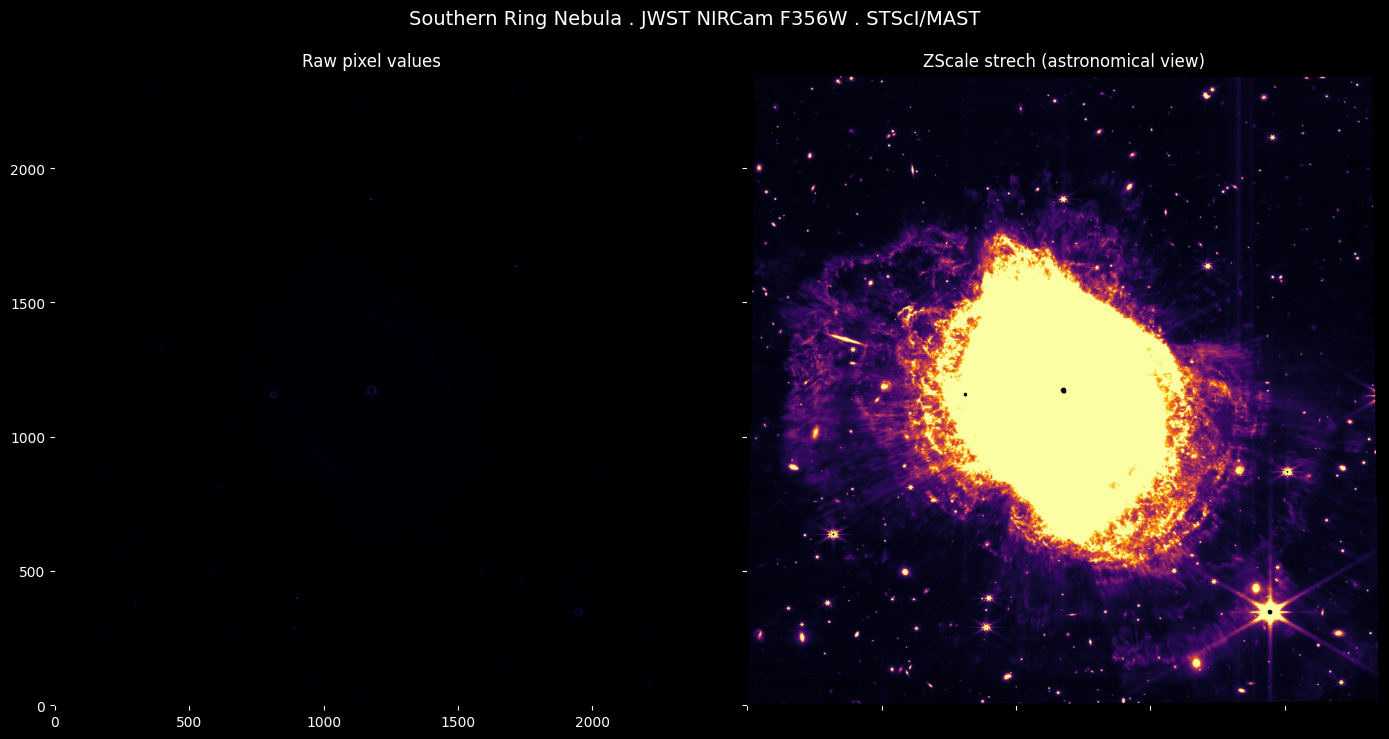

Saved as southern_ring_nebula.png


In [ ]:
# Visualize the Southern Ring Nebula - JWST NIRCam F356W

fig, axes = plt.subplots(1,2, figsize=(14,7))
fig.patch.set_facecolor('black')

# Left: Raw data (what it looks like without scaling)
axes[0].imshow(image_data, cmap='inferno', origin='lower')
axes[0].set_title('Raw pixel values', color='white', fontsize=12)
axes[0].set_facecolor('black')
axes[0].tick_params(colors='white')

# Right: ZScale stretch (how astronomers actually view images)
norm = ImageNormalize(image_data, interval=ZScaleInterval())
axes[1].imshow(image_data, norm=norm, cmap='inferno', origin='lower')
axes[1].set_title('ZScale strech (astronomical view)', color='white', fontsize=12)
axes[1].set_facecolor('black')
axes[1].tick_params(color='white')

plt.suptitle('Southern Ring Nebula . JWST NIRCam F356W . STScI/MAST', color='white', fontsize=14, y=1.02)

plt.tight_layout()
plt.savefig('southern_ring_nebula.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print("Saved as southern_ring_nebula.png")

In [ ]:
# Add context - what are we actually looking at?
print("=" * 50)
print("SOUTHERN RING NEBULA (NGC 3132)")
print("=" * 50)
print(f"\nTelescope:    James Webb Space Telescope (JWST)")
print(f"Instrument:   NIRCam")
print(f"Filter:       F356W (Near-Infrared, 3.56 microns)")
print(f"Image size:   {image_data.shape[1]} x {image_data.shape[0]} pixels")
print(f"Distance:     ~2,500 light years from Earth")
print(f"Object:       Planetary nebula — a dying star's")
print(f"              final exhalation into space")
print(f"\nData source:  MAST Archive · STScI · NASA")
print(f"Pipeline:     JWST Level 3 calibrated mosaic (i2d)")
print(f"\nVisualization notes:")
print(f"  Left:  Raw pixel values — dynamic range too large")
print(f"         for direct display")
print(f"  Right: ZScale interval stretch — standard astronomical")
print(f"         display algorithm, reveals true structure")

SOUTHERN RING NEBULA (NGC 3132)

Telescope:    James Webb Space Telescope (JWST)
Instrument:   NIRCam
Filter:       F356W (Near-Infrared, 3.56 microns)
Image size:   2356 x 2348 pixels
Distance:     ~2,500 light years from Earth
Object:       Planetary nebula — a dying star's
              final exhalation into space

Data source:  MAST Archive · STScI · NASA
Pipeline:     JWST Level 3 calibrated mosaic (i2d)

Visualization notes:
  Left:  Raw pixel values — dynamic range too large
         for direct display
  Right: ZScale interval stretch — standard astronomical
         display algorithm, reveals true structure
